# Product Analytics & User Behavior Intelligence Platform

## Project Overview

This project focuses on understanding user behavior on an e-commerce platform.

I'll use Python to explore customer interactions, identify engagement patterns, and analyze factors that influence conversions.

The insights from this analysis can help improve user experience and support better product decisions.

## Import Required Libraries

In [6]:
# Import libraries for data analysis

import pandas as pd
import numpy as np

# Libraries for visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Display charts inside the notebook
%matplotlib inline

# Set a default visualization style
sns.set_style("whitegrid")

## Load Dataset

Let's load the dataset and make sure it has been imported correctly before starting the analysis.

In [7]:
# Load the dataset

df = pd.read_csv(r"C:\Users\ANAND\Product-Analytics-Platform\data\retail_user_behavior_100k.csv")

# Display the first five rows
df.head()

,session_id,user_id,timestamp_utc,event_index,user_action,product_id,category,brand,price,channel,device_type,region,traffic_source,time_spent_sec,session_length,interaction_count,is_conversion,drop_off_flag
0,S0000001,U000372,2026-01-08T02:34:40Z,1,view,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,25,4,1,0,0
1,S0000001,U000372,2026-01-08T02:35:20Z,2,wishlist,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,28,4,2,0,0
2,S0000001,U000372,2026-01-08T02:35:43Z,3,view,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,5,4,3,0,0
3,S0000001,U000372,2026-01-08T02:36:13Z,4,drop,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,16,4,4,0,1
4,S0000002,U004812,2026-01-29T11:07:27Z,1,view,P1836,Groceries,OrganicCo,212.37,mobile,tablet,UK,direct,15,4,1,0,0


## Dataset Dimensions

Before exploring the dataset further, I want to check how many records and features are available.

In [8]:
# Check dataset dimensions

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 108584
Number of Columns : 18


## Dataset Information

Before moving ahead, I want to understand the structure of the dataset. This will help me identify the available columns, their data types, and whether there are any missing values that need attention.

In [9]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108584 entries, 0 to 108583
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   session_id         108584 non-null  str    
 1   user_id            108584 non-null  str    
 2   timestamp_utc      108584 non-null  str    
 3   event_index        108584 non-null  int64  
 4   user_action        108584 non-null  str    
 5   product_id         108584 non-null  str    
 6   category           108584 non-null  str    
 7   brand              108584 non-null  str    
 8   price              108584 non-null  float64
 9   channel            108584 non-null  str    
 10  device_type        108584 non-null  str    
 11  region             108584 non-null  str    
 12  traffic_source     108584 non-null  str    
 13  time_spent_sec     108584 non-null  int64  
 14  session_length     108584 non-null  int64  
 15  interaction_count  108584 non-null  int64  
 16  is_conversion

## Column Names

Now I want to take a closer look at all the available columns.

This helps me understand what information is available before I start cleaning the data or performing any analysis.

In [10]:
# Display all column names

df.columns

Index(['session_id', 'user_id', 'timestamp_utc', 'event_index', 'user_action',
       'product_id', 'category', 'brand', 'price', 'channel', 'device_type',
       'region', 'traffic_source', 'time_spent_sec', 'session_length',
       'interaction_count', 'is_conversion', 'drop_off_flag'],
      dtype='str')

## Preview the Dataset

Before starting the analysis, I want to inspect the first few records to understand how the data is organized and verify that each column contains the expected values.

In [11]:
# Display the first five records

df.head()

,session_id,user_id,timestamp_utc,event_index,user_action,product_id,category,brand,price,channel,device_type,region,traffic_source,time_spent_sec,session_length,interaction_count,is_conversion,drop_off_flag
0,S0000001,U000372,2026-01-08T02:34:40Z,1,view,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,25,4,1,0,0
1,S0000001,U000372,2026-01-08T02:35:20Z,2,wishlist,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,28,4,2,0,0
2,S0000001,U000372,2026-01-08T02:35:43Z,3,view,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,5,4,3,0,0
3,S0000001,U000372,2026-01-08T02:36:13Z,4,drop,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,16,4,4,0,1
4,S0000002,U004812,2026-01-29T11:07:27Z,1,view,P1836,Groceries,OrganicCo,212.37,mobile,tablet,UK,direct,15,4,1,0,0


## Summary Statistics

Next, I'll generate summary statistics to better understand the numerical features, including their ranges, averages, and overall distribution.

In [12]:
# Generate summary statistics for numerical columns

df.describe()

,event_index,price,time_spent_sec,session_length,interaction_count,is_conversion,drop_off_flag
count,108584.000000,108584.000000,108584.000000,108584.000000,108584.000000,108584.000000,108584.000000
mean,3.834626,249.497547,17.828317,6.669251,3.834626,0.038707,0.127063
std,2.238094,145.627749,9.356853,2.038962,2.238094,0.192897,0.333045
min,1.000000,7.290000,3.000000,3.000000,1.000000,0.000000,0.000000
25%,2.000000,119.950000,11.000000,5.000000,2.000000,0.000000,0.000000
50%,4.000000,253.850000,18.000000,7.000000,4.000000,0.000000,0.000000
75%,5.000000,376.080000,24.000000,8.000000,5.000000,0.000000,0.000000
max,13.000000,499.860000,64.000000,13.000000,13.000000,1.000000,1.000000


In [13]:
# Check the number of missing values in each column

df.isnull().sum()

session_id           0
user_id              0
timestamp_utc        0
event_index          0
user_action          0
product_id           0
category             0
brand                0
price                0
channel              0
device_type          0
region               0
traffic_source       0
time_spent_sec       0
session_length       0
interaction_count    0
is_conversion        0
drop_off_flag        0
dtype: int64

## Check for Duplicate Records

Before starting the analysis, I want to verify whether the dataset contains duplicate records. Duplicate entries can lead to incorrect calculations and affect the reliability of the analysis.

In [14]:
# Check the number of duplicate rows

duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 0


## Explore Categorical Features

Before starting the analysis, I want to understand the categorical columns in the dataset.

Checking the unique values helps me identify the available categories, detect any unexpected values, and better understand the structure of the data.

In [15]:
# Display the number of unique values in each column

df.nunique()

session_id            18000
user_id                6806
timestamp_utc        108020
event_index              13
user_action               6
product_id             1200
category                  8
brand                    33
price                  1189
channel                   3
device_type               4
region                    9
traffic_source            7
time_spent_sec           56
session_length           11
interaction_count        13
is_conversion             2
drop_off_flag             2
dtype: int64

## Review Data Types

Before moving into data cleaning and analysis, I want to review the data types of all columns. This helps identify columns that may require conversion for better analysis.

In [16]:
# Display the data type of each column

df.dtypes

session_id               str
user_id                  str
timestamp_utc            str
event_index            int64
user_action              str
product_id               str
category                 str
brand                    str
price                float64
channel                  str
device_type              str
region                   str
traffic_source           str
time_spent_sec         int64
session_length         int64
interaction_count      int64
is_conversion          int64
drop_off_flag          int64
dtype: object

## Convert Timestamp to Datetime

The `timestamp_utc` column is currently stored as text. Converting it to a datetime format will make it easier to perform time-based analysis, such as trends by month, day, or hour.

In [17]:
# Convert the timestamp column to datetime

df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])

# Verify the updated data type

df["timestamp_utc"].dtype

datetime64[us, UTC]

## Verify the Timestamp Conversion

After converting the timestamp column, I want to verify that the values are displayed correctly and can now be used for time-based analysis.

In [18]:
# Display the first five timestamps

df["timestamp_utc"].head()

0   2026-01-08 02:34:40+00:00
1   2026-01-08 02:35:20+00:00
2   2026-01-08 02:35:43+00:00
3   2026-01-08 02:36:13+00:00
4   2026-01-29 11:07:27+00:00
Name: timestamp_utc, dtype: datetime64[us, UTC]

## Feature Engineering

To support time-based analysis, I'll create additional columns from the timestamp. These features will help analyze user activity across different years, months, days, hours, and weekdays.

In [19]:
# Create time-based features from the timestamp

df["year"] = df["timestamp_utc"].dt.year
df["month"] = df["timestamp_utc"].dt.month
df["month_name"] = df["timestamp_utc"].dt.month_name()
df["day"] = df["timestamp_utc"].dt.day
df["day_of_week"] = df["timestamp_utc"].dt.day_name()
df["hour"] = df["timestamp_utc"].dt.hour

# Display the newly created features

df[[
    "timestamp_utc",
    "year",
    "month",
    "month_name",
    "day",
    "day_of_week",
    "hour"
]].head()

,timestamp_utc,year,month,month_name,day,day_of_week,hour
0,2026-01-08 02:34:40+00:00,2026,1,January,8,Thursday,2
1,2026-01-08 02:35:20+00:00,2026,1,January,8,Thursday,2
2,2026-01-08 02:35:43+00:00,2026,1,January,8,Thursday,2
3,2026-01-08 02:36:13+00:00,2026,1,January,8,Thursday,2
4,2026-01-29 11:07:27+00:00,2026,1,January,29,Thursday,11


## Business Question 1:
## What actions do users perform?

Before analyzing user behavior, I want to understand the different actions users perform while interacting with the platform.

In [20]:
# Display unique user actions

df["user_action"].unique()

<StringArray>
['view', 'wishlist', 'drop', 'add_to_cart', 'click', 'purchase']
Length: 6, dtype: str

## Business Question 2: How frequently does each user action occur?

Now I want to understand how users interact with the platform by counting the frequency of each action. This will help identify the most common behaviors and provide a high-level view of the user journey.

In [21]:
# Count the occurrences of each user action

action_counts = df["user_action"].value_counts()

action_counts

user_action
view           44245
click          27735
drop           13797
add_to_cart    11642
wishlist        6962
purchase        4203
Name: count, dtype: int64

## User Action Distribution

To better understand customer behavior, I'll calculate the percentage distribution of each user action. This provides a clearer view of how users progress through the platform.

In [22]:
# Calculate the percentage distribution of user actions

action_percentage = (
    df["user_action"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

action_percentage

user_action
view           40.75
click          25.54
drop           12.71
add_to_cart    10.72
wishlist        6.41
purchase        3.87
Name: proportion, dtype: float64

## Visualizing User Actions

A visual representation of user actions makes it easier to identify the most common behaviors and compare different stages of user interaction across the platform.

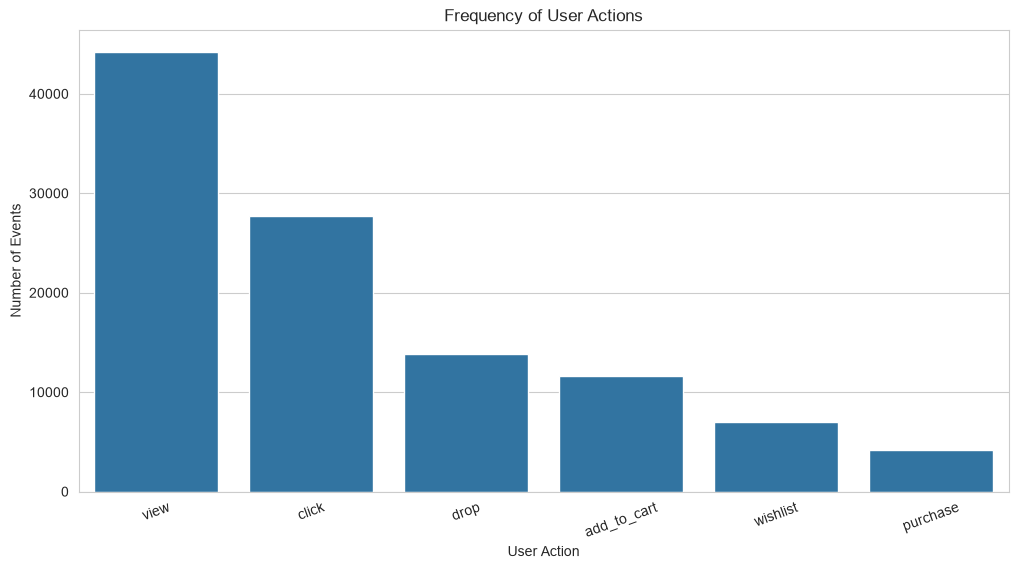

In [23]:
# Count user actions
action_counts = df["user_action"].value_counts()

# Create the chart
plt.figure(figsize=(12,6))

sns.barplot(
    x=action_counts.index,
    y=action_counts.values
)

# Add title and labels
plt.title("Frequency of User Actions")
plt.xlabel("User Action")
plt.ylabel("Number of Events")

# Rotate x-axis labels for better readability
plt.xticks(rotation=20)

# Display the chart
plt.show()

# Product Category Analysis

Understanding how users interact with different product categories helps identify which categories receive the highest engagement. These insights can support product strategy, inventory planning, and marketing campaigns.

In [24]:
# Count user interactions by product category

category_counts = df["category"].value_counts()

category_counts

category
Groceries      13879
Accessories    13740
Sports         13739
Shoes          13648
Apparel        13562
Home           13475
Electronics    13376
Beauty         13165
Name: count, dtype: int64

## Brand Analysis

Brands play an important role in customer purchasing decisions. In this section, I'll analyze user interactions across different brands to identify which brands receive the highest engagement.

In [25]:
# Count user interactions by brand

brand_counts = df["brand"].value_counts()

# Display the top 10 brands

brand_counts.head(10)

brand
Nike          11275
Adidas         9250
Puma           7036
Target         3795
Bose           3598
Ray-Ban        3557
Wilson         3477
Neutrogena     3159
OrganicCo      3123
DailyFresh     3032
Name: count, dtype: int64

## Top 10 Brands by User Interaction

This visualization highlights the brands with the highest number of user interactions. Understanding brand engagement helps identify which brands attract the most customer attention and can guide further analysis of conversions and sales performance.

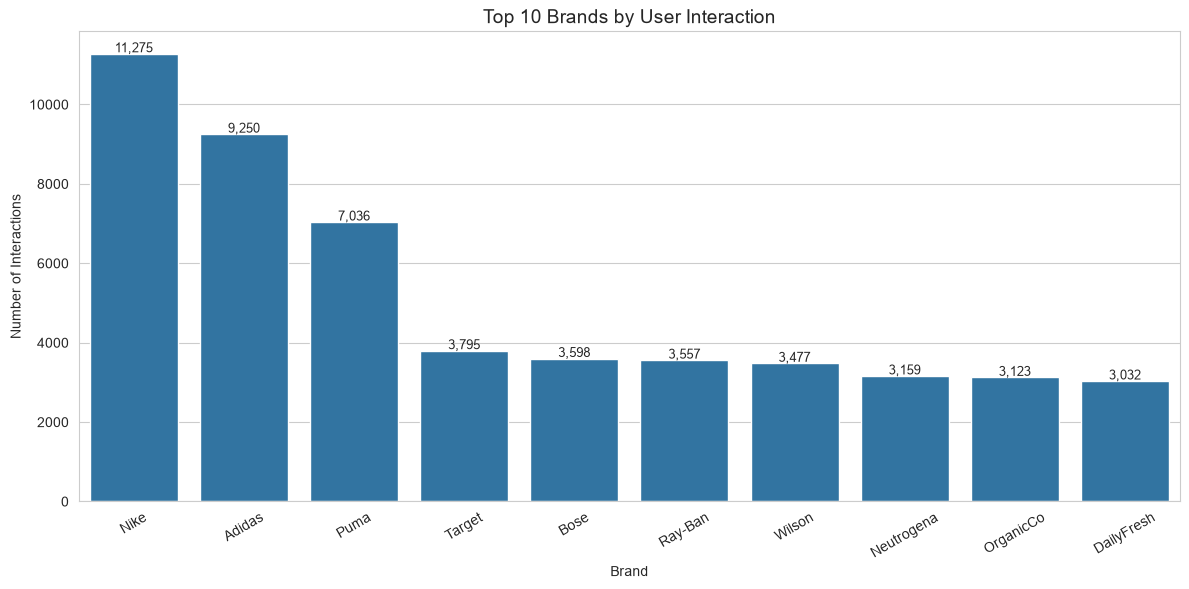

In [26]:
# Select the top 10 brands
top_brands = df["brand"].value_counts().head(10)

# Create the figure
plt.figure(figsize=(12, 6))

# Create the bar chart
ax = sns.barplot(
    x=top_brands.index,
    y=top_brands.values
)

# Add value labels
for i, value in enumerate(top_brands.values):
    ax.text(i, value + 40, f"{value:,}", ha="center", fontsize=9)

# Chart formatting
plt.title("Top 10 Brands by User Interaction", fontsize=14)
plt.xlabel("Brand")
plt.ylabel("Number of Interactions")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()